# Joint Notebook for All Datasets

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure
import tifffile
from scipy.ndimage import median_filter
import pandas as pd
import function_definitions as source
from tqdm import tqdm
from scipy.ndimage import label

In [2]:
# Stylistic Settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'figure.titlesize': 18,
    'figure.titleweight': 'bold',
    'legend.frameon': False,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

POPULATION_COLORS = {
    "merged_BC": {
        "primary": "#49325C",
        "secondary": "#E07A5F",
    },
    "merged_BC_all_channels": {
        "primary": "#008f87",
        "secondary": "#F4A261",
    },
    "PC_merged_all": {
        "primary": "#ffa600",
        "secondary": "#264653",
    },
}

UTILITY_COLORS = {
    "rose": "#A13D63",
    "sage": "#6B8F71",
    "slate": "#3D5A73",
    "mustard": "#D9A441",
}

COLORS = list(UTILITY_COLORS.values())

## Data Loading
The data for this notebook should be structured this way:

<pre>
data_root/
├── cell_images/
│   ├── merged_BC/
│   ├── {Population Name}/
│   └── ...
├── cellpose_masks/
│   ├── merged_BC/
│   ├── {Population Name}/
│   └── ...
└── nuclear_masks/
    ├── merged_BC/
    ├── {Population Name}/
    └── ...
</pre>

cell_images should contain 9 slide .ome.tif files (no preprocessing required)

cellpose_masks - Cellpose generated .npy files

nuclear_masks - .tif images with binary masks

In [3]:
data_root = Path(r"C:\Users\jakub\Documents\Piotr\mask_analysis\data")

populations = ["merged_BC", "merged_BC_all_channels", "PC_merged_all"]

## Looping through provided populations and extracting data

The script will try to process every population specified in the list above. The output is a dictionary - *dfs* - containing pandas DataFrames structured like below. Additionally, all Dataframes will be saved to a .csv file in the directory of this notebook.

|Population|Image id|Image Path|Event ID|N Contributing Cellpose Cells|Cellpose Area|Nucleus Area|Nucleus/Cellpose|Average Nucleus Signal|Circularity 1|Circularity 2|Eccentricity|
|---|---|---|---|---|---|---|---|---|---|---|---|
| - | - | - | - | - | - | - | - | - | - | - | - |

In [4]:
dfs = {}
for population in populations:
    try:
        dfs[population] = source.process_population(population, data_root)
    except (AssertionError, FileNotFoundError) as e:
        print(f"Skipping {population}: {e}")

260 images detected.


Processing merged_BC: 100%|██████████| 260/260 [00:01<00:00, 185.28it/s]


220 images detected.


Processing merged_BC_all_channels: 100%|██████████| 220/220 [00:01<00:00, 182.13it/s]


Skipping PC_merged_all: The numbers of files in given directories do not match. Images: 2114, Cellpose: 2114, Nuclear: 0.


In [5]:
converted_populations = list(dfs.keys())

n_populations = len(converted_populations)

### What is an 'event'?
For our purposes, an 'event' is a singular, free flowing cell or a close aggregation of cells sharing DAPI signature. There may be multiple events per image, hence *Event ID* parameter. The *N Contributing Cellpose Cells* tracks how many Cellpose masks share pixels with given event.

In the output of the cell below, the circled areas correspond to separate events.

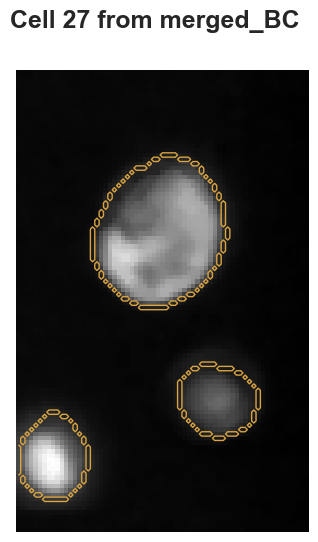

In [6]:
from skimage.segmentation import find_boundaries

p_idx = 0       # Change this variable to access different cell populations
idx = 27         # Change this variable to access other images

dapi_channel, events_mask = source.visualize_events(populations[p_idx], idx)

fig, ax = plt.subplots(figsize=(6, 6))
fig.suptitle(f"Cell {idx} from {populations[p_idx]}")
ax.imshow(dapi_channel, cmap='gray')
boundaries = find_boundaries(events_mask, mode='outer', connectivity=1)
ax.contour(boundaries, colors=UTILITY_COLORS["mustard"], linewidths=1)
ax.axis('off')
plt.show()

### Event type comparison
This plot tells how many detected events contain more than one Cellpose cell.

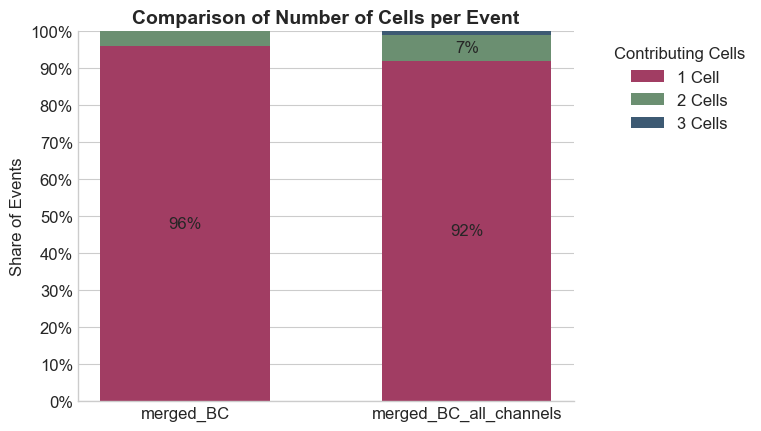

In [7]:
fig, ax = plt.subplots()

series_dict = {}
for p in converted_populations:
    counts = dfs[p]["N Contributing Cellpose Cells"].value_counts(normalize=True).sort_index()
    series_dict[p] = counts

plot_data = pd.DataFrame(series_dict).fillna(0)
bottom = np.zeros(len(converted_populations))

for cell_count, row in plot_data.iterrows():
    shares_array = row.values

    p_bar = ax.bar(converted_populations, shares_array, label=f'{cell_count} Cells' if cell_count>1 else '1 Cell', bottom=bottom, width=0.6, color=COLORS[cell_count-1])
    
    ax.bar_label(p_bar, label_type='center', fmt=lambda x: f'{x*100:.0f}%' if x > 0.05 else '')

    bottom += shares_array


ax.set_ylabel('Share of Events')
ax.set_title('Comparison of Number of Cells per Event')

ax.set_yticks(np.arange(0, 1.1, 0.1))
ax.set_yticklabels([f'{int(y*100)}%' for y in np.arange(0, 1.1, 0.1)])
ax.legend(title='Contributing Cells', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()


# Joint Circularity Analysis
In this notebook, the circularity is measured in three following ways.

*$\text{Circularity 1} = \frac{4\pi \cdot Area}{Perimeter^2}$

$\text{Circularity 2} = \frac{Area}{Convex Area}$

$\text{Eccentricity --> eccentricity of an ellipse with the same second moments as the pixel mask}$

***

All those features take values in the set [0, 1], however for *Circularity1* and *Circularity2* the score of 1 means perfect circle, whereas for *Eccentricity* it is the score 0. To mitigate values being over 1 due to numerical errors, all outputs above 1 were clipped. All outputs exceeding 1.1 were logged in the output of cell 7 (*process_population()*). If nothing is printed, then no events exceeded this threshold.

**We used Crofton perimeter, to mitigate the impact of jagged edges*

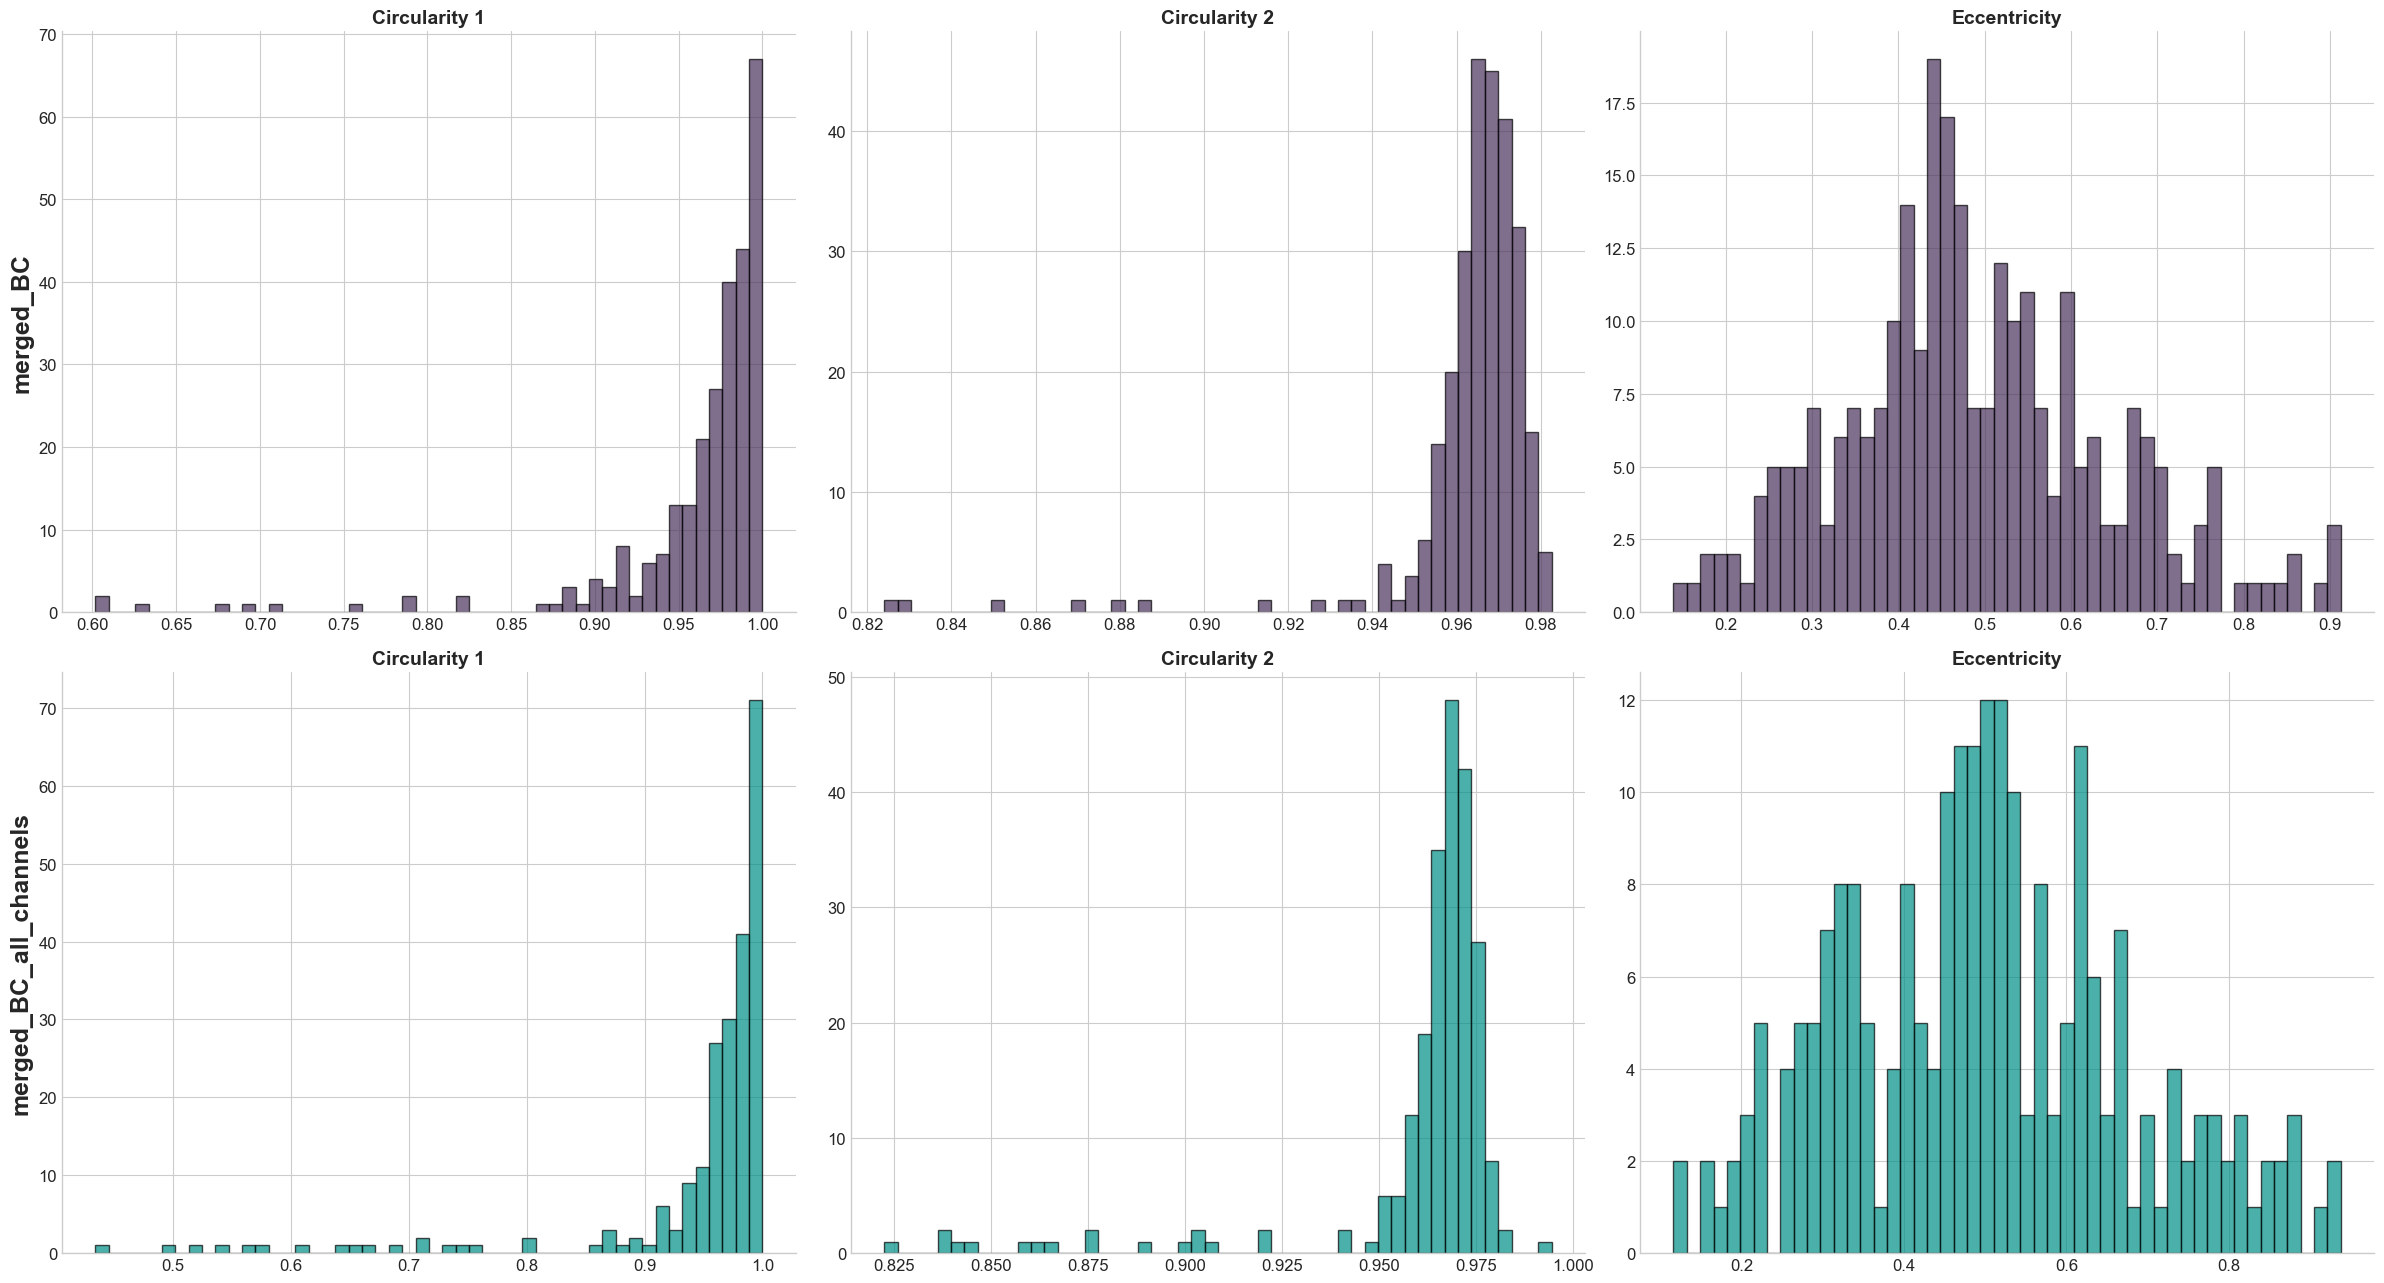

In [8]:
fig, ax = plt.subplots(n_populations, 3, figsize=(24, 13))

for i, p in enumerate(converted_populations):
    df = dfs[p]

    ax[i, 0].set_ylabel(f"{p}", fontsize=18, fontweight='bold')

    ax[i, 0].set_title("Circularity 1")
    ax[i, 0].hist(df["Circularity 1"].dropna(), bins=50, edgecolor='black', alpha=0.7, color=POPULATION_COLORS[p]["primary"])

    ax[i, 1].set_title("Circularity 2")
    ax[i, 1].hist(df["Circularity 2"].dropna(), bins=50, edgecolor='black', alpha=0.7, color=POPULATION_COLORS[p]["primary"])

    ax[i, 2].set_title("Eccentricity")
    ax[i, 2].hist(df["Eccentricity"].dropna(), bins=50, edgecolor='black', alpha=0.7, color=POPULATION_COLORS[p]["primary"])

plt.tight_layout()
plt.show()
    

#### Given Those histograms, we chose circularity thresholds:
$\begin{equation}\text{max circularity 1} = 0.92\end{equation}$
$\begin{equation}\text{max circularity 2} = 0.956\end{equation}$
$\begin{equation}\text{min eccentricity} = 0.7\end{equation}$

That means, all images exceeding those thresholds will be classified as noncircular

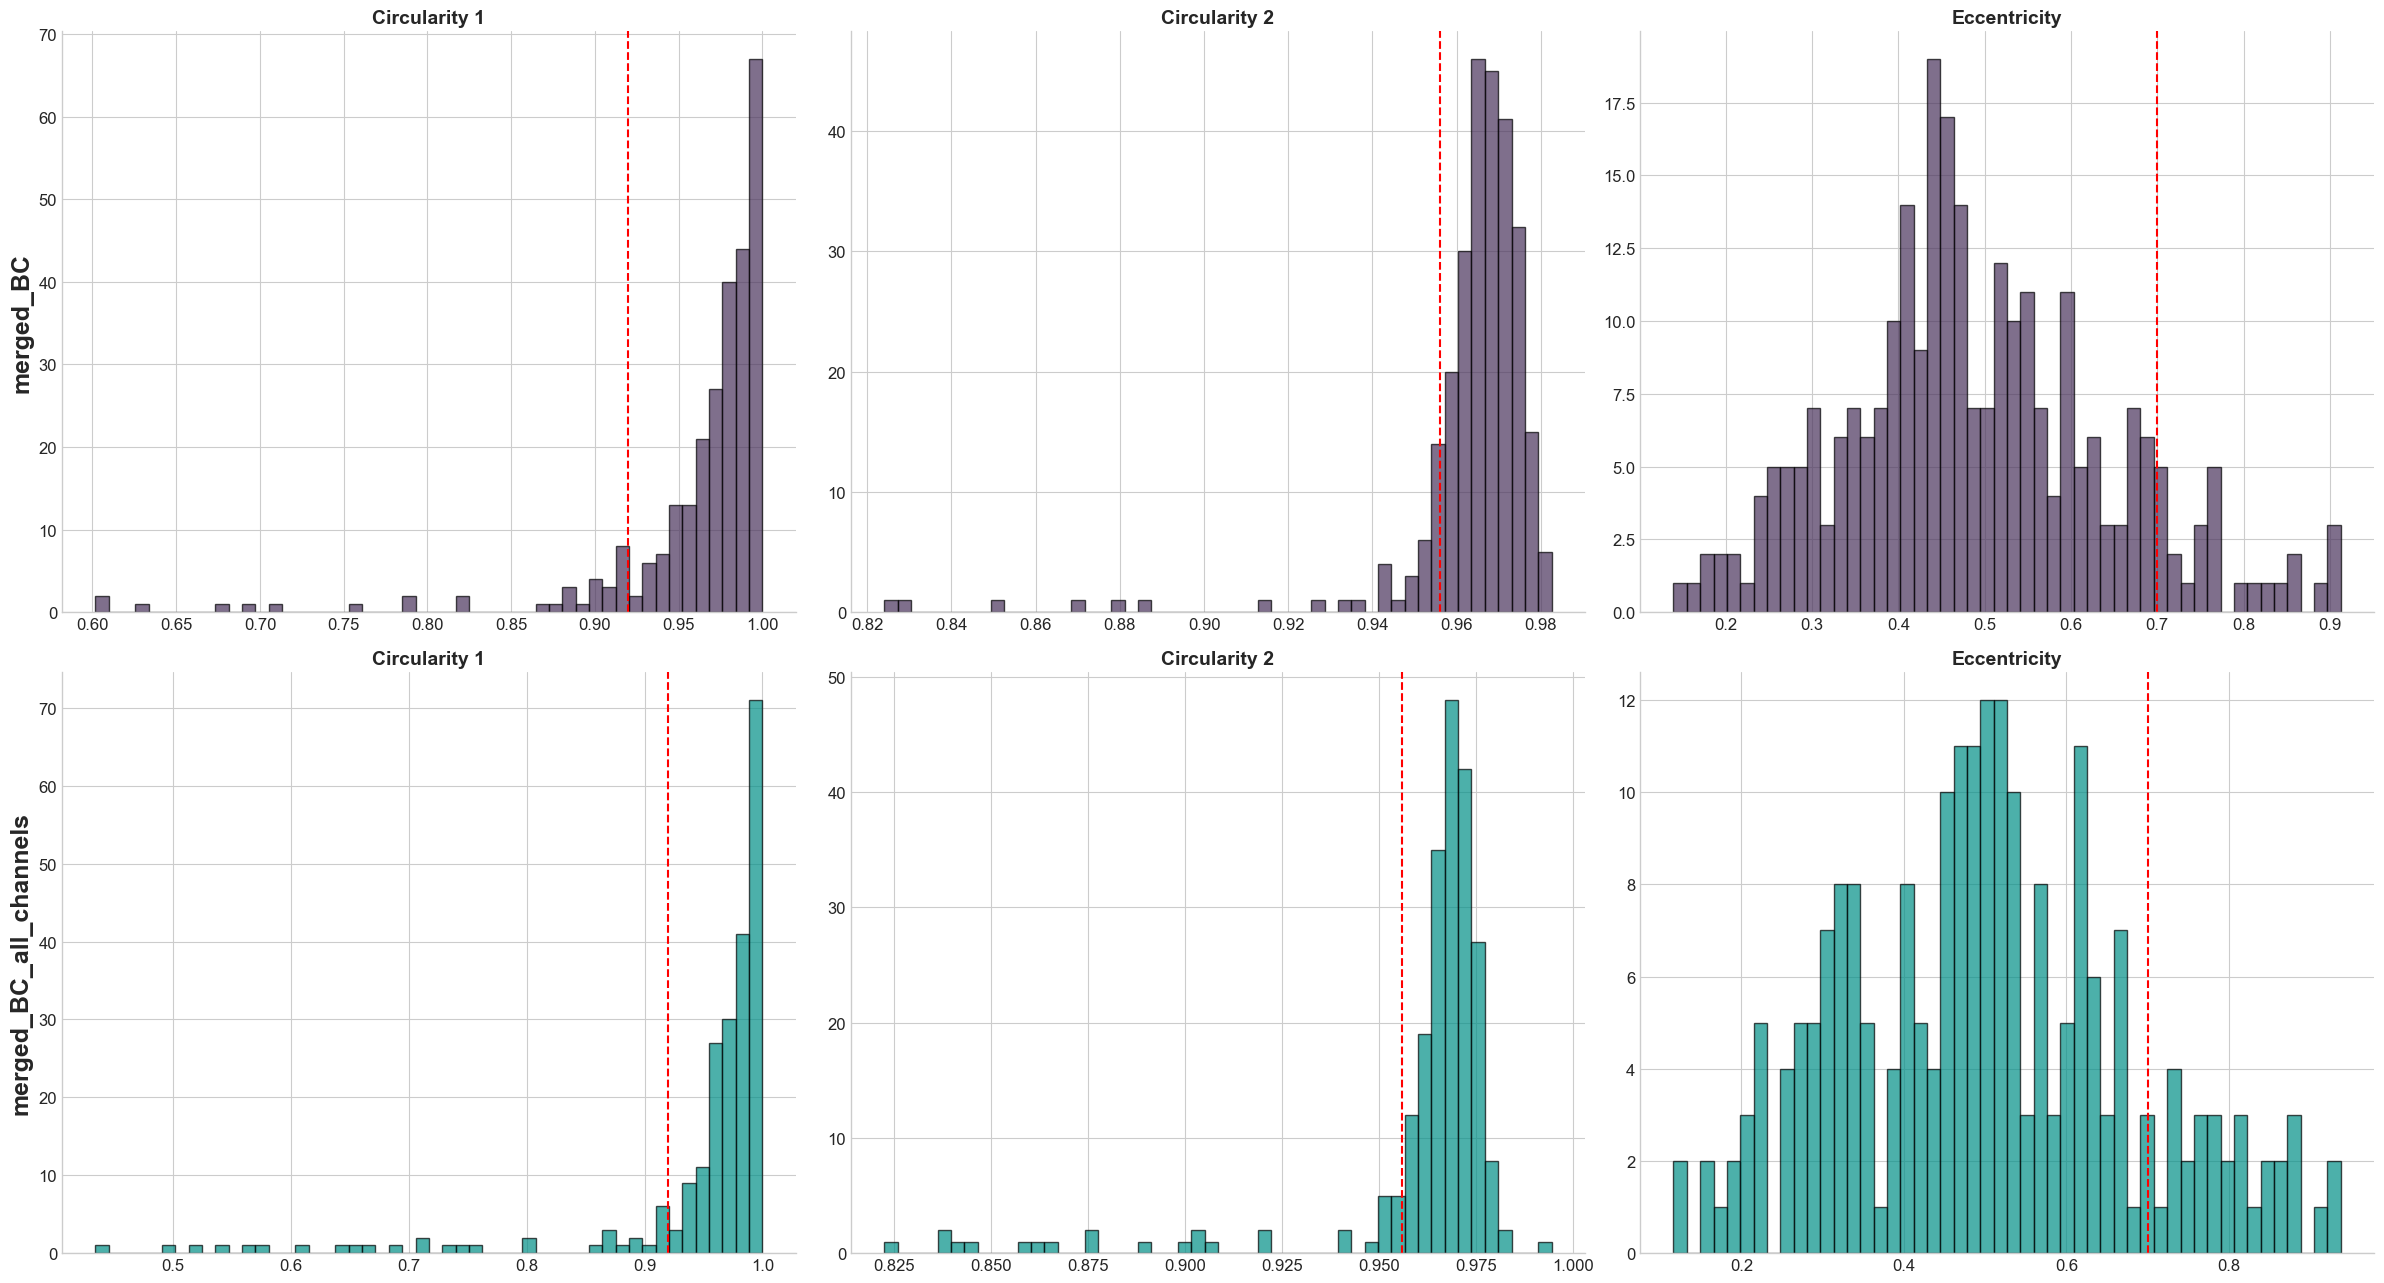

In [9]:
THRESHOLDS = {"circ1": 0.92, "circ2": 0.956, "ecc": 0.7}

fig, ax = plt.subplots(n_populations, 3, figsize=(24, 13))

for i, p in enumerate(converted_populations):
    df = dfs[p]

    ax[i, 0].set_ylabel(f"{p}", fontsize=18, fontweight='bold')

    ax[i, 0].set_title("Circularity 1")
    ax[i, 0].hist(df["Circularity 1"].dropna(), bins=50, edgecolor='black', alpha=0.7, color=POPULATION_COLORS[p]["primary"])
    ax[i, 0].axvline(THRESHOLDS["circ1"], color='r', linestyle='--')

    ax[i, 1].set_title("Circularity 2")
    ax[i, 1].hist(df["Circularity 2"].dropna(), bins=50, edgecolor='black', alpha=0.7, color=POPULATION_COLORS[p]["primary"])
    ax[i, 1].axvline(THRESHOLDS["circ2"], color='r', linestyle='--')

    ax[i, 2].set_title("Eccentricity")
    ax[i, 2].hist(df["Eccentricity"].dropna(), bins=50, edgecolor='black', alpha=0.7, color=POPULATION_COLORS[p]["primary"])
    ax[i, 2].axvline(THRESHOLDS["ecc"], color='r', linestyle='--')

plt.tight_layout()
plt.show()

In [10]:
# Calculating masses above those thresholds
for i, p in enumerate(converted_populations):
    df = dfs[p]

    mass_below_circ1 = (df["Circularity 1"] < THRESHOLDS["circ1"]).sum() / len(df["Circularity 1"])
    mass_below_circ2 = (df["Circularity 2"] < THRESHOLDS["circ2"]).sum() / len(df["Circularity 2"])
    mass_above_ecc = (df["Eccentricity"] > THRESHOLDS["ecc"]).sum() / len(df["Eccentricity"])

    print(p+":")
    print(f"""
        Circularity 1 mass below {THRESHOLDS["circ1"]}: {float(100*mass_below_circ1):.2f}%\t\tCircularity 2 mass below {THRESHOLDS["circ2"]}: {float(100*mass_below_circ2):.2f}%\t\tEccentricity mass above {THRESHOLDS["ecc"]}: {float(100*mass_above_ecc):.2f}%
    """)
    print("\n\n")

merged_BC:

        Circularity 1 mass below 0.92: 11.40%		Circularity 2 mass below 0.956: 12.13%		Eccentricity mass above 0.7: 9.19%
    



merged_BC_all_channels:

        Circularity 1 mass below 0.92: 13.84%		Circularity 2 mass below 0.956: 12.95%		Eccentricity mass above 0.7: 13.39%
    





### Finding Noncircular Events

In [11]:
non_circulars = {}

for i, p in enumerate(converted_populations):
    df = dfs[p]

    found = df[(df["Circularity 1"] < THRESHOLDS["circ1"]) | (df["Circularity 2"] < THRESHOLDS["circ2"]) | (df["Eccentricity"] > THRESHOLDS["ecc"])]
    non_circulars[p] = found

    unique_imgs = np.unique(found["Image ID"])

    print(f"[{p}] Noncircular events found in {len(unique_imgs)} unique images.")

[merged_BC] Noncircular events found in 49 unique images.
[merged_BC_all_channels] Noncircular events found in 43 unique images.


### Run This Cell to Copy All Noncircular Events to a Separate Folder

In [12]:
import shutil

for p in converted_populations:
    found = non_circulars[p]
    unique_paths = found["Image Path"].unique()

    out_dir = Path(r".\non_circulars")/p
    out_dir.mkdir(exist_ok=True, parents=True)


    for tif_path in tqdm(unique_paths, f"Copying {p} Files"):
        shutil.copy2(tif_path, out_dir)

Copying merged_BC_all_channels Files: 100%|██████████| 43/43 [00:00<00:00, 1532.47it/s]


# DAPI Intensity and Nucleus/Cellpose Area Analysis

All values calculated per *event*.

* Cellpose Area - summed number of pixels of every Cellpose mask contributing to given *event*
* Nucleus Area - similarily, number of pixels of a DAPI mask intersected with Cellpose objects (<110px objects were removed)
* Nucleus/Cellpose - *Cellpose Area*/*Nucleus Area*
* Average DAPI Intensity - mean of DAPI channel pixel's intensities interseted with *event*

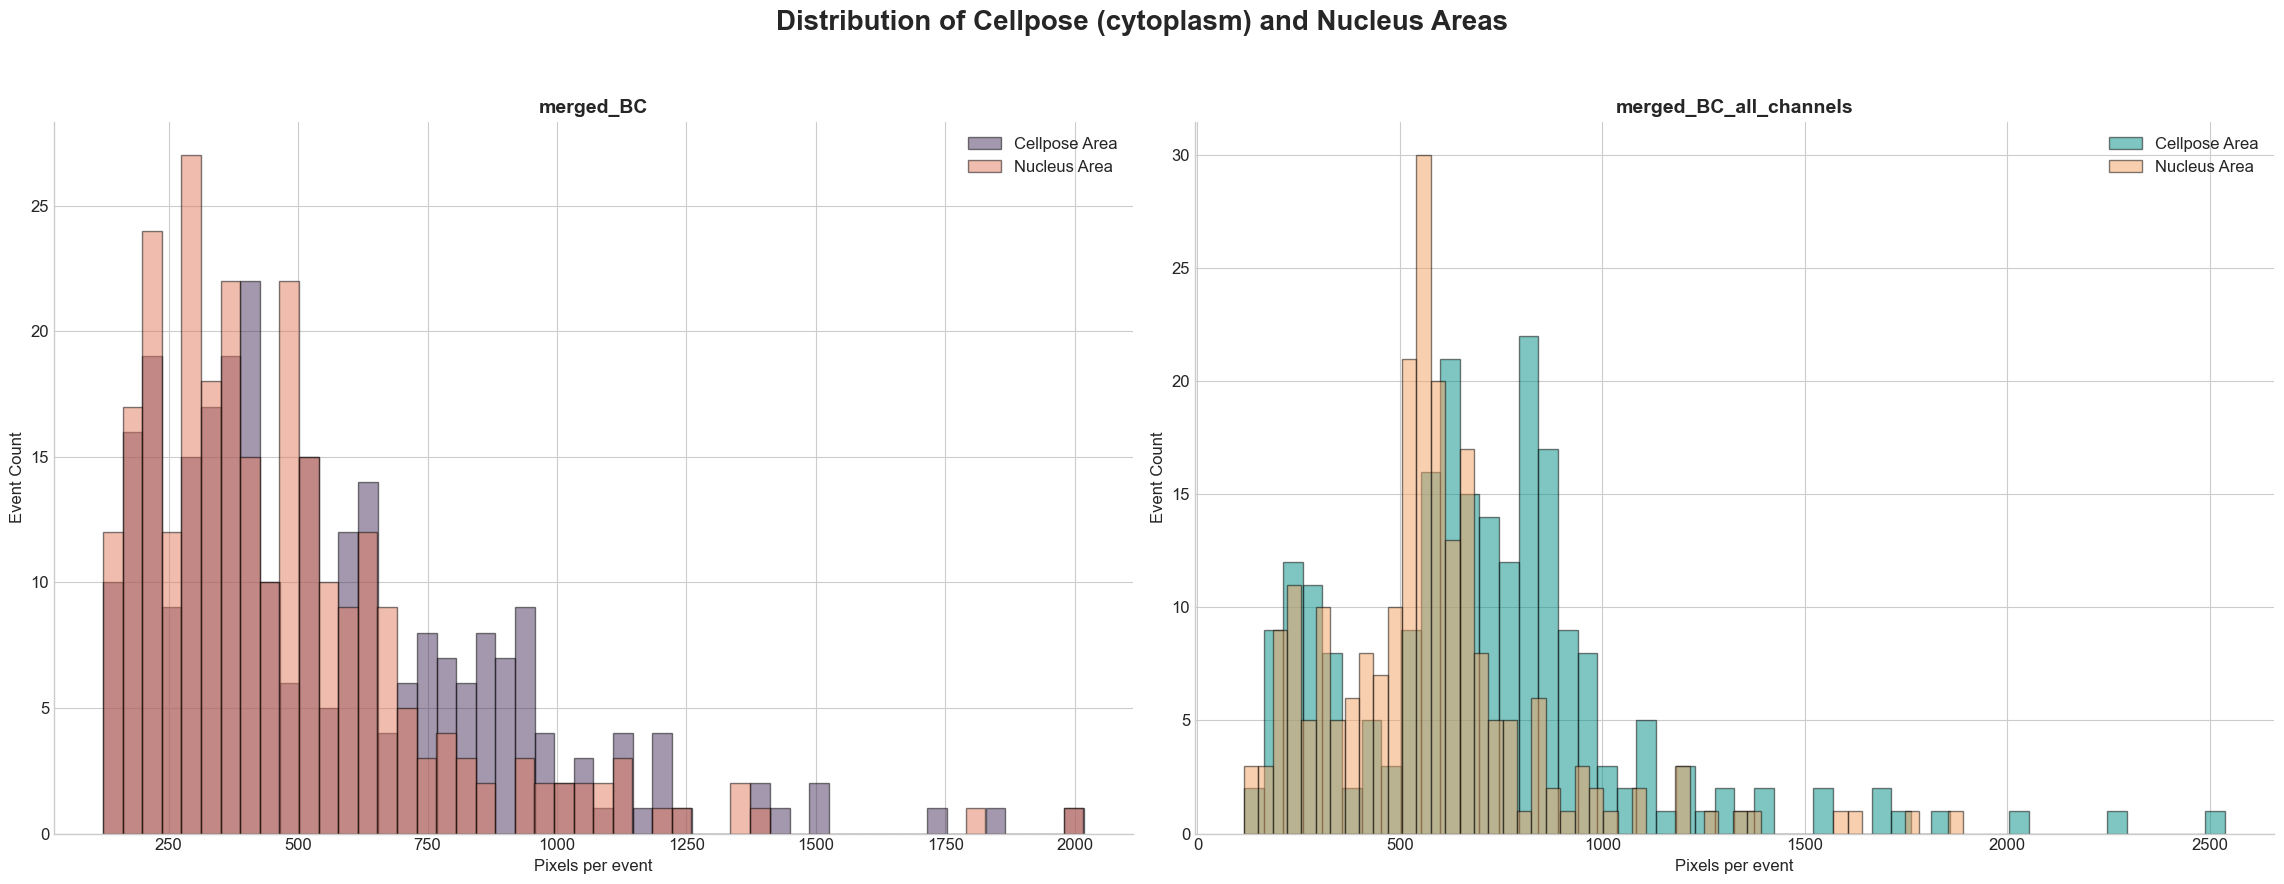

In [13]:
fig, ax = plt.subplots(1, n_populations, figsize=(23, 9))

fig.suptitle("Distribution of Cellpose (cytoplasm) and Nucleus Areas", fontweight='bold', fontsize=20)

for i, p in enumerate(converted_populations):
    df = dfs[p]

    ax[i].set_title(p, fontweight='bold')

    ax[i].hist(df["Cellpose Area"].dropna(), bins=50, alpha=0.5, label="Cellpose Area", edgecolor='black', color=POPULATION_COLORS[p]["primary"])
    ax[i].hist(df["Nucleus Area"].dropna(), bins=50, alpha=0.5, label="Nucleus Area", edgecolor='black', color=POPULATION_COLORS[p]["secondary"])
    ax[i].set_xlabel("Pixels per event")
    ax[i].set_ylabel("Event Count")
    ax[i].legend()

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

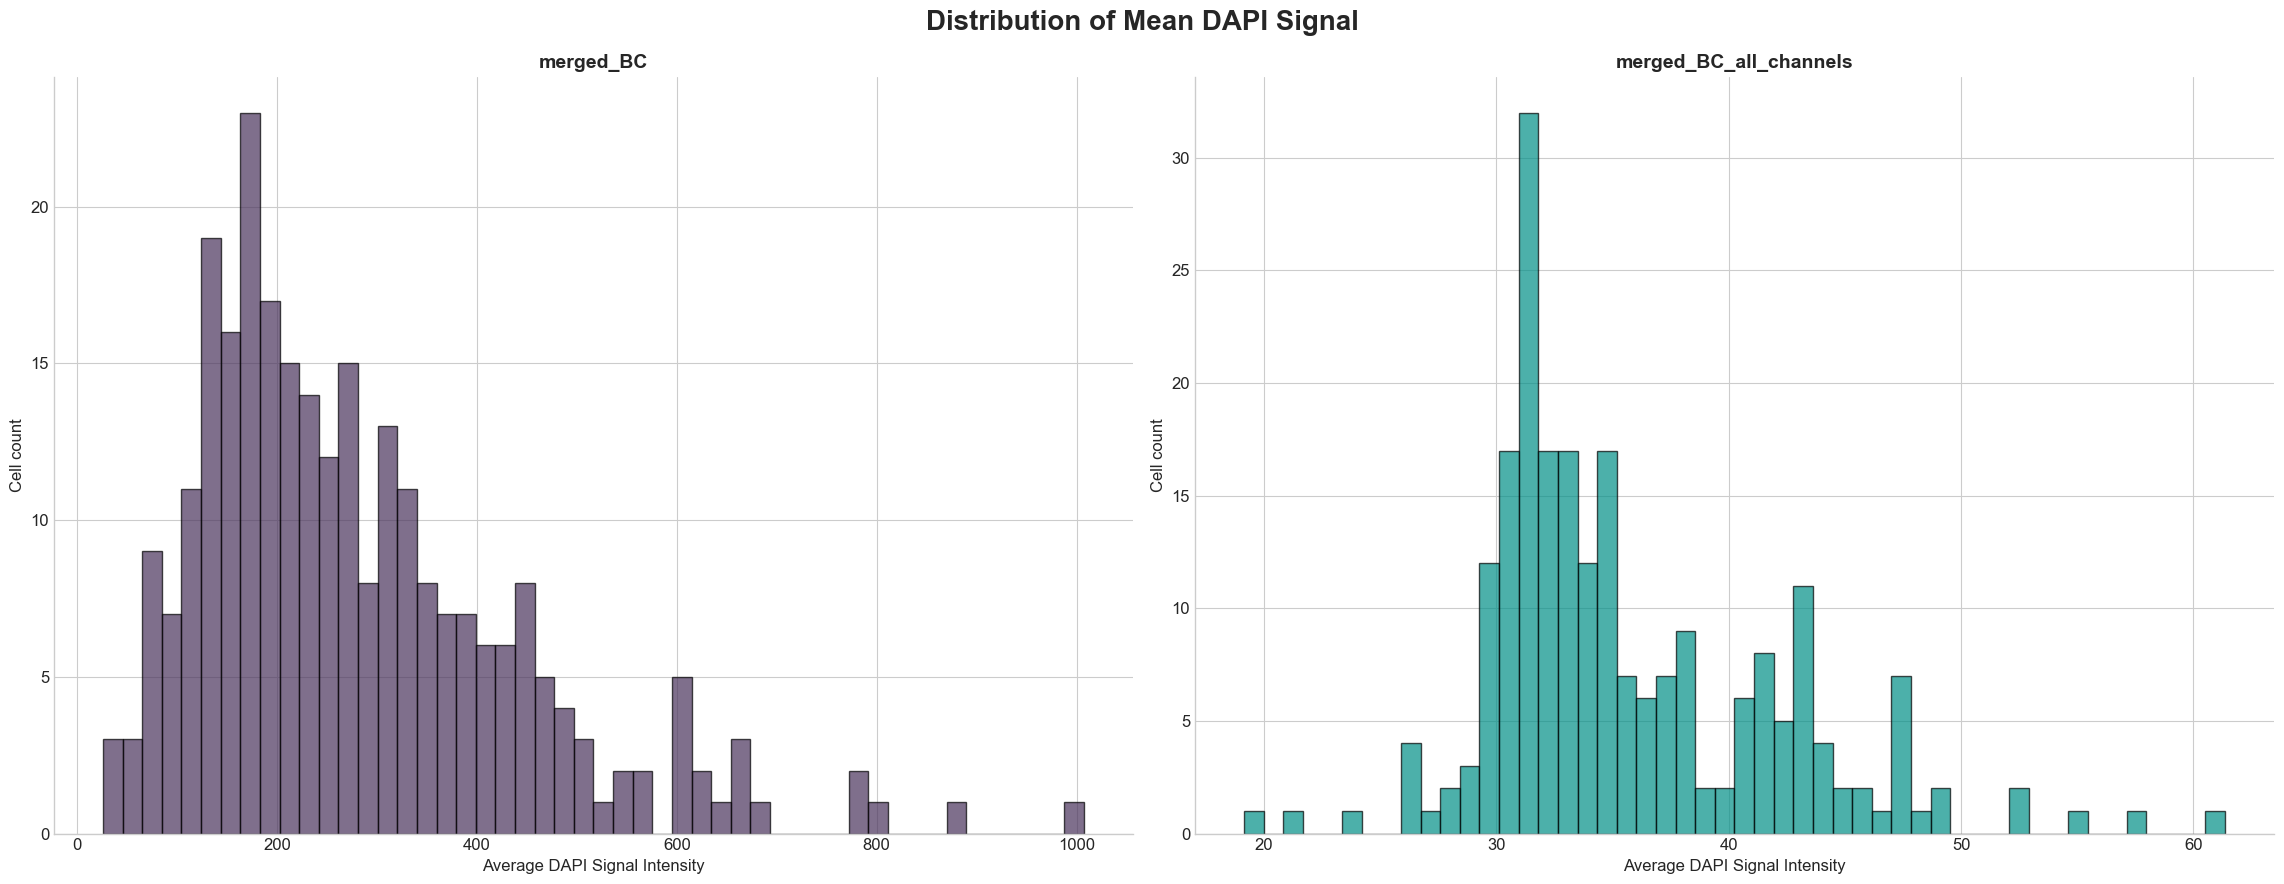

In [14]:
fig, ax = plt.subplots(1, n_populations, figsize=(23, 9))

fig.suptitle("Distribution of Mean DAPI Signal", fontsize=20, fontweight='bold')

for i, p in enumerate(converted_populations):
    df = dfs[p]

    ax[i].hist(df["Average Nucleus Signal"].dropna(), bins=50, edgecolor='black', alpha=0.7, color=POPULATION_COLORS[p]["primary"])
    ax[i].set_xlabel("Average DAPI Signal Intensity")
    ax[i].set_ylabel("Cell count")
    ax[i].set_title(p, fontweight='bold')
 
plt.tight_layout()
plt.show()

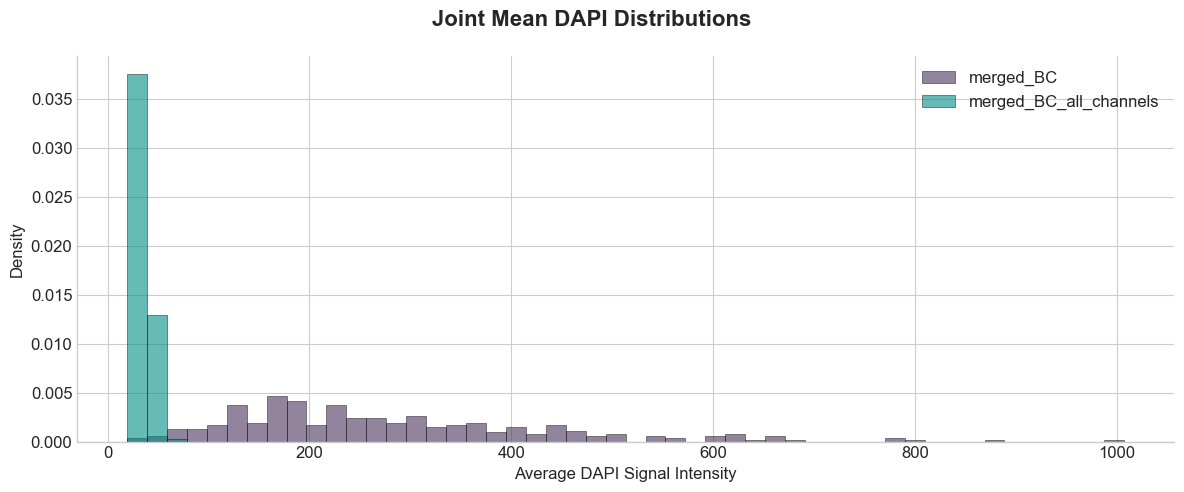

In [15]:
# fig, ax = plt.subplots(figsize=(12, 5))

# fig.suptitle("Joint Mean DAPI Distributions", fontsize=16, fontweight='bold')

# for i, p in enumerate(converted_populations):
#     df = dfs[p]
    
#     ax.hist(df["Average Nucleus Signal"].dropna(), bins=50, linewidth=2.5, alpha=0.7, log=False, label=str(p), density=True)

# ax.set_ylabel("Cell Count")
# ax.set_xlabel("Average DAPI Signal Intensity")
# ax.legend()

# plt.tight_layout()
# plt.show()

combined = pd.concat([dfs[p]["Average Nucleus Signal"].dropna() for p in converted_populations])
shared_bins = np.histogram_bin_edges(combined, bins=50)

fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle("Joint Mean DAPI Distributions", fontsize=16, fontweight='bold')

for p in converted_populations:
    df = dfs[p]
    ax.hist(df["Average Nucleus Signal"].dropna(), bins=shared_bins, density=True, alpha=0.6, label=p, edgecolor='black', linewidth=0.5, color=POPULATION_COLORS[p]["primary"])

ax.set_ylabel("Density")
ax.set_xlabel("Average DAPI Signal Intensity")
ax.legend()
plt.tight_layout()
plt.show()

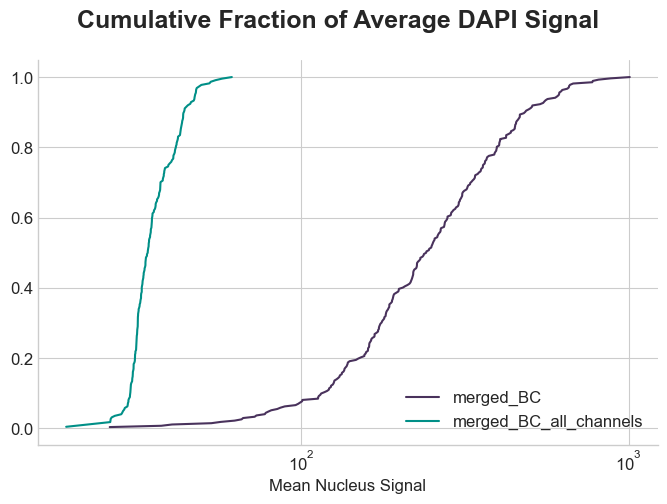

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))

fig.suptitle("Cumulative Fraction of Average DAPI Signal")
ax.set_xscale('log')

for p in converted_populations:
    vals = np.sort(dfs[p]["Average Nucleus Signal"].dropna())
    y = np.arange(1, len(vals)+1) / len(vals)
    ax.plot(vals, y, color=POPULATION_COLORS[p]["primary"], label=p)
ax.set_xlabel("Mean Nucleus Signal")
ax.set_ylabel("")
ax.legend()
plt.show()

## Comparison Nucleus Area/Cellpose Are Quotient Values

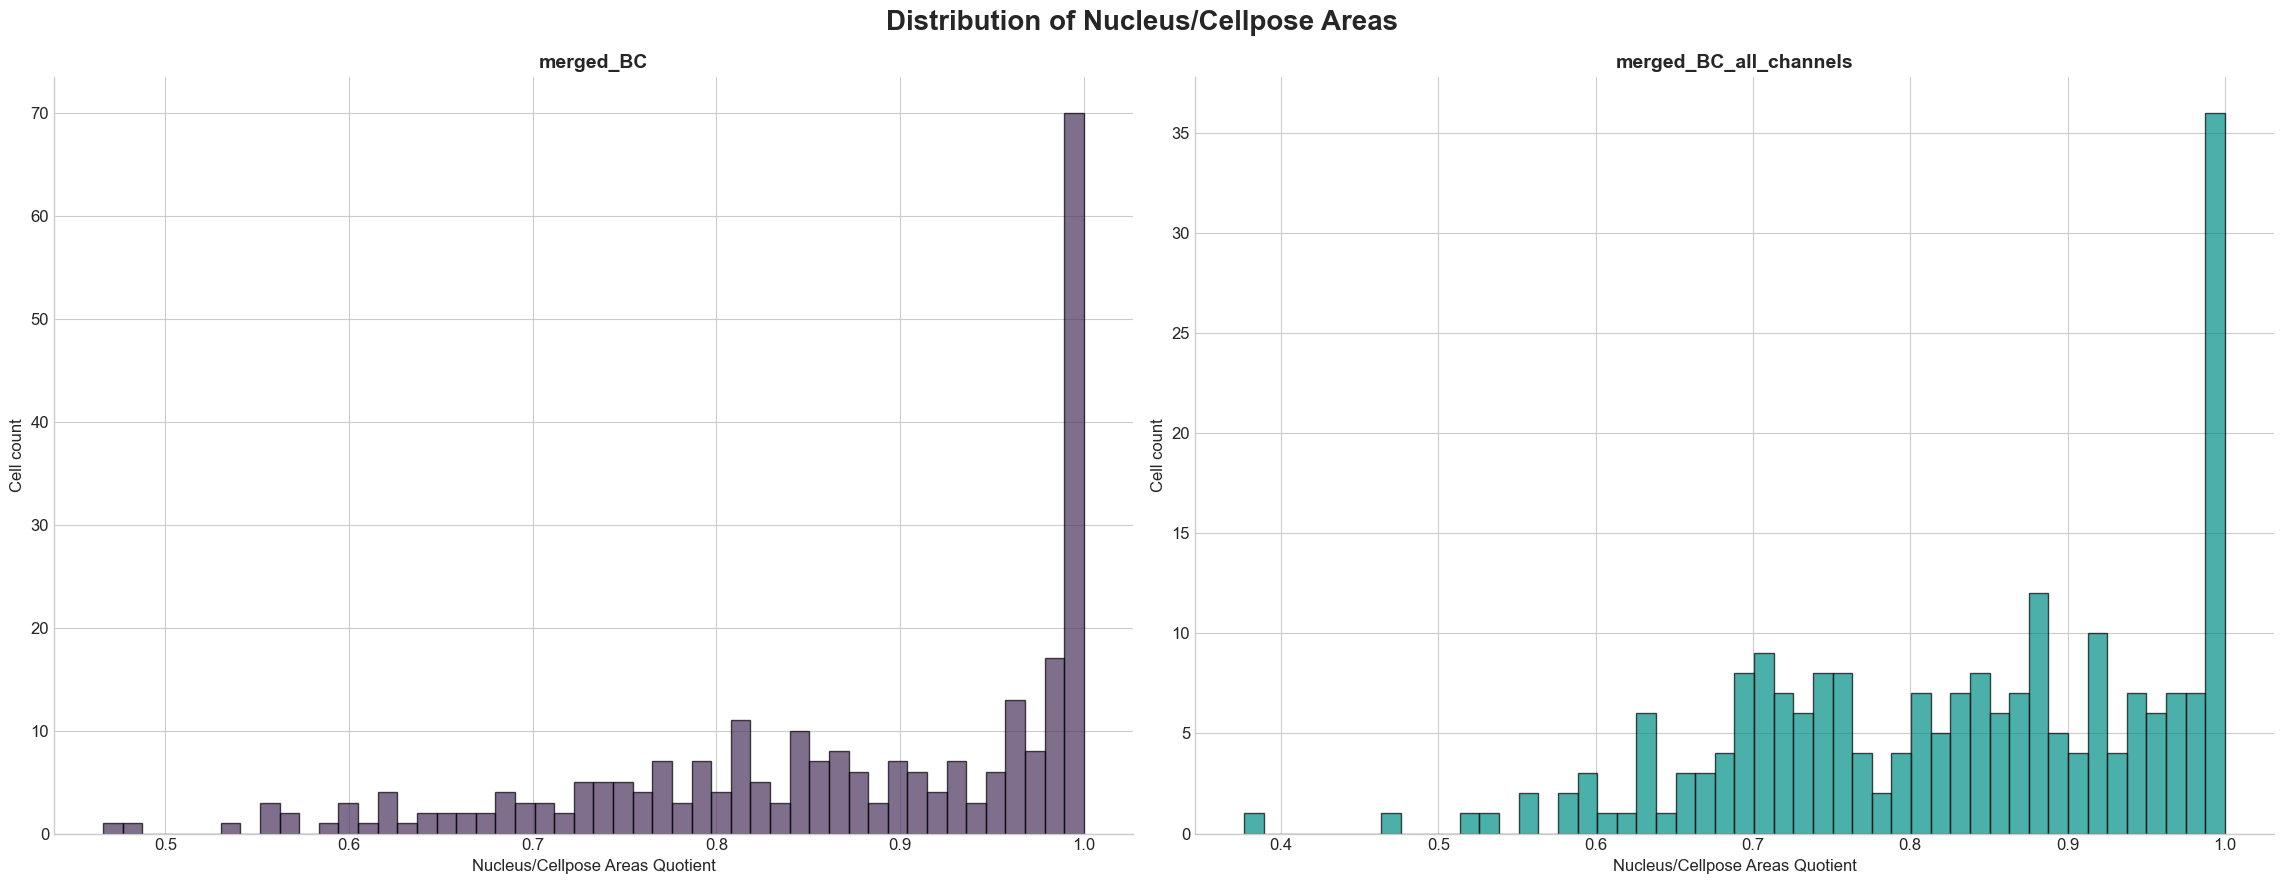

In [17]:
fig, ax = plt.subplots(1, n_populations, figsize=(23, 9))

fig.suptitle("Distribution of Nucleus/Cellpose Areas", fontsize=20, fontweight='bold')

for i, p in enumerate(converted_populations):
    df = dfs[p]

    ax[i].hist(df["Nucleus/Cellpose"].dropna(), bins=50, edgecolor='black', alpha=0.7, color=POPULATION_COLORS[p]["primary"])
    ax[i].set_xlabel("Nucleus/Cellpose Areas Quotient")
    ax[i].set_ylabel("Cell count")
    ax[i].set_title(p, fontweight='bold')
 
plt.tight_layout()
plt.show()

**The disproportional number of 1.0 values is due to some masks being bigger than the cells themselves. Because of how the code is designed, those cases will always evaluate to 1.*

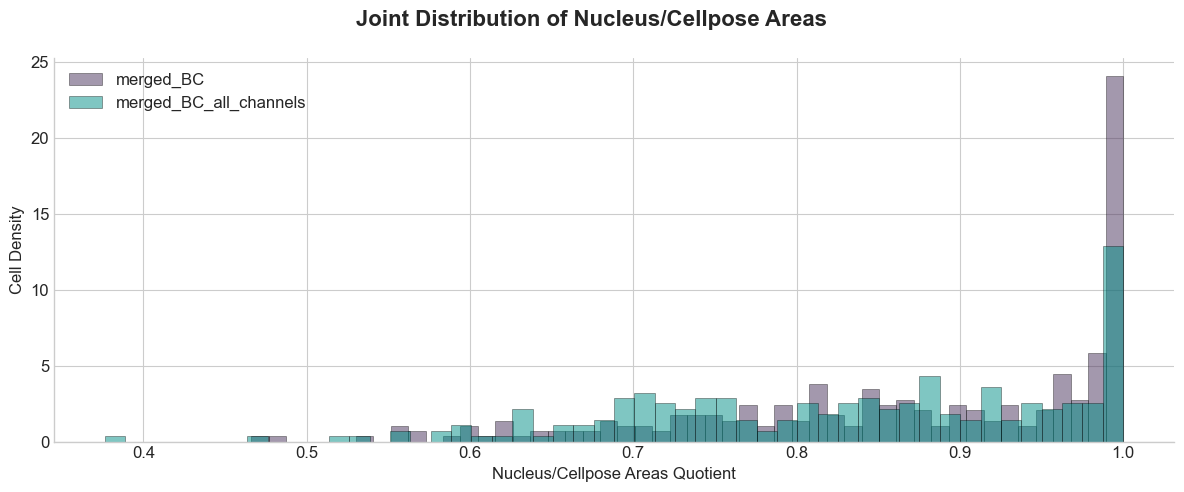

In [18]:
fig, ax = plt.subplots(figsize=(12, 5))

fig.suptitle("Joint Distribution of Nucleus/Cellpose Areas", fontsize=16, fontweight='bold')

for i, p in enumerate(converted_populations):
    df = dfs[p]
    
    ax.hist(df["Nucleus/Cellpose"].dropna(), bins=50, linewidth=0.5, alpha=0.5, log=False, label=str(p), edgecolor='black', density=True, color=POPULATION_COLORS[p]["primary"])

ax.set_ylabel("Cell Density")
ax.set_xlabel("Nucleus/Cellpose Areas Quotient")
ax.legend()

plt.tight_layout()
plt.show()

**The disproportional number of 1.0 values is due to some masks being bigger than the cells themselves. Because of how the code is designed, those cases will always evaluate to 1.*